# Chapter 18. Quanvolutional Neural Networks

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 3**

## 학습 목표
- 작은 이미지(sklearn digits 8x8)에 quanvolutional layer 적용
- 양자 회로가 어떻게 "필터" 역할을 하는지 시각화
- 일반 CNN과 quanvolutional CNN 비교

In [1]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.manual_seed(0)

## 18.1 데이터 — sklearn digits (8×8 이미지)

데이터: (360, 8, 8), 클래스 분포: [178 182]


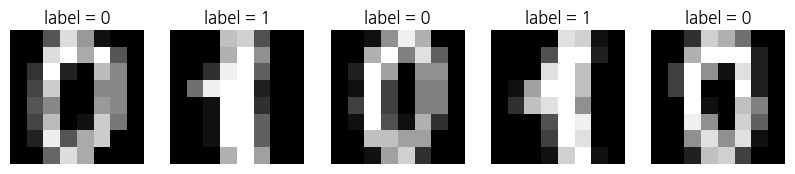

In [2]:
data = load_digits()
# 8x8 이미지를 0~1로 정규화
images = data.images / 16.0
labels = data.target
# 이진 분류로 단순화 (0 vs 1)
mask = labels < 2
images = images[mask]; labels = labels[mask]
print(f'데이터: {images.shape}, 클래스 분포: {np.bincount(labels)}')

# 일부 이미지 시각화
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for ax, img, lab in zip(axes, images[:5], labels[:5]):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'label = {lab}')
    ax.axis('off')
plt.show()

## 18.2 Quanvolutional layer 정의
2×2 패치를 4큐비트 양자 회로로 변환한다 (회로 파라미터는 고정).

In [3]:
n_q = 4
dev = qml.device('default.qubit', wires=n_q)

# 고정된 무작위 회로 파라미터 (학습 안 함)
rng = np.random.RandomState(0)
rand_params = rng.uniform(0, 2 * np.pi, (2, n_q, 3))

@qml.qnode(dev)
def quanv_circuit(patch):
    # 2x2 = 4 픽셀을 4큐비트의 회전 각도로
    for i in range(n_q):
        qml.RY(np.pi * patch[i], wires=i)
    # 고정된 무작위 ansatz
    qml.StronglyEntanglingLayers(rand_params, wires=range(n_q))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_q)]

# 테스트
patch = np.array([0.5, 0.7, 0.2, 0.9])
out = quanv_circuit(patch)
print(f'패치 입력 → 4채널 출력: {np.round(out, 3)}')

패치 입력 → 4채널 출력: [ 0.131 -0.098  0.095  0.13 ]


## 18.3 이미지에 quanvolution 적용
8×8 이미지 → stride 2의 2×2 패치 → 4×4의 4채널 feature map

feature map shape: (4, 4, 4)


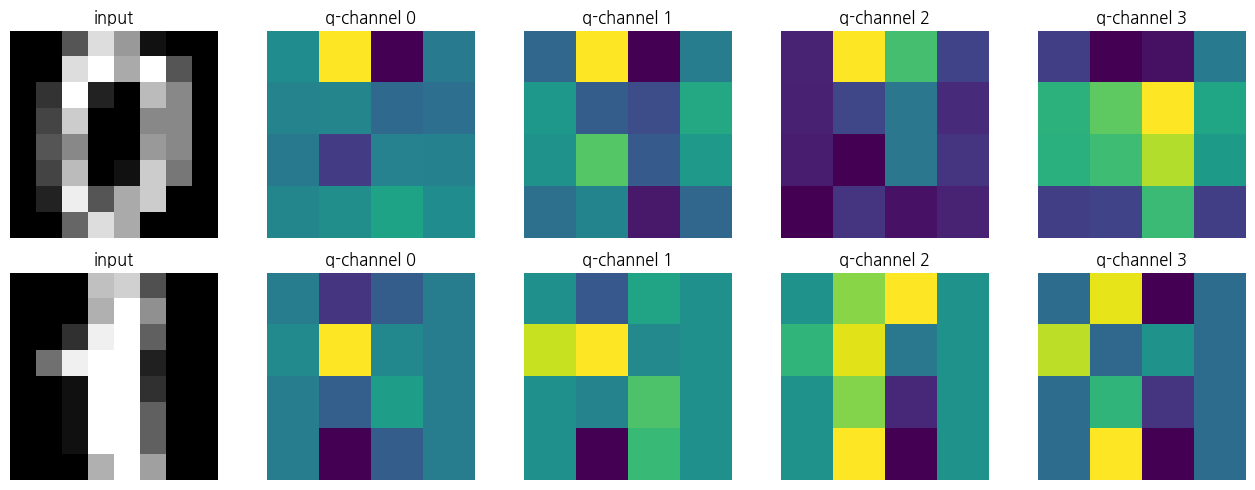

In [4]:
def apply_quanv(image):
    out = np.zeros((4, 4, 4))  # (height, width, channels)
    for i in range(4):
        for j in range(4):
            patch = [
                image[2 * i, 2 * j],
                image[2 * i, 2 * j + 1],
                image[2 * i + 1, 2 * j],
                image[2 * i + 1, 2 * j + 1],
            ]
            out[i, j] = quanv_circuit(patch)
    return out

# 처음 2개 이미지에만 적용 (시간 절약)
sample_features = [apply_quanv(images[i]) for i in range(2)]
print(f'feature map shape: {sample_features[0].shape}')

# 시각화
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for row, (img, feat) in enumerate(zip(images[:2], sample_features)):
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title('input')
    axes[row, 0].axis('off')
    for ch in range(4):
        axes[row, ch + 1].imshow(feat[:, :, ch], cmap='viridis')
        axes[row, ch + 1].set_title(f'q-channel {ch}')
        axes[row, ch + 1].axis('off')
plt.tight_layout(); plt.show()

**해석.** 같은 양자 회로지만 4개의 다른 측정으로 4채널 feature map이 만들어진다. 각 채널은 서로 다른 비선형 특징을 강조한다.

## 18.4 전체 데이터에 적용 (소량)
시간 절약을 위해 50개 이미지만 사용한다.

In [5]:
# 50개 이미지에 quanvolution 적용
N = 50
X_subset = images[:N]
y_subset = labels[:N]
X_features = np.array([apply_quanv(img) for img in X_subset])
print(f'feature 데이터: {X_features.shape}')  # (N, 4, 4, 4)

# Flatten 후 학습/테스트 분리
X_flat = X_features.reshape(N, -1)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_flat, y_subset, test_size=0.3, random_state=0,
)
X_tr = torch.tensor(X_tr, dtype=torch.float32)
X_te = torch.tensor(X_te, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)
y_te = torch.tensor(y_te, dtype=torch.long)
print(f'학습: {X_tr.shape}, 테스트: {X_te.shape}')

feature 데이터: (50, 4, 4, 4)
학습: torch.Size([35, 64]), 테스트: torch.Size([15, 64])


학습: torch.Size([35, 64]), 테스트: torch.Size([15, 64])


## 18.5 분류 헤드 학습
Quanvolutional feature 위에 단순한 MLP를 얹는다.

테스트 정확도: 1.000


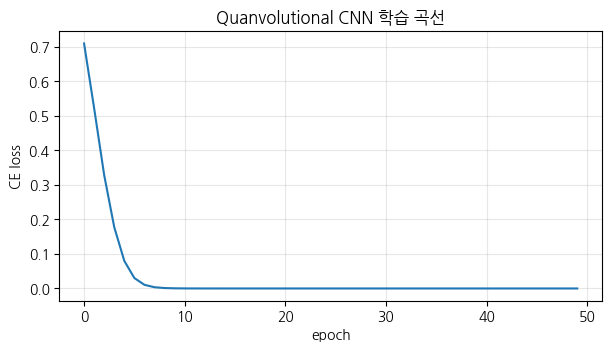

In [6]:
model = nn.Sequential(
    nn.Linear(64, 16),  # 4*4*4 = 64
    nn.ReLU(),
    nn.Linear(16, 2),
)
opt = torch.optim.Adam(model.parameters(), lr=0.05)
crit = nn.CrossEntropyLoss()

history = []
for ep in range(50):
    opt.zero_grad()
    loss = crit(model(X_tr), y_tr)
    loss.backward()
    opt.step()
    history.append(loss.item())

with torch.no_grad():
    acc = (model(X_te).argmax(1) == y_te).float().mean().item()
print(f'테스트 정확도: {acc:.3f}')

plt.figure(figsize=(7, 3.5))
plt.plot(history); plt.xlabel('epoch'); plt.ylabel('CE loss')
plt.title('Quanvolutional CNN 학습 곡선')
plt.grid(alpha=0.3); plt.show()

## 18.6 정리
- Quanvolution = 양자 회로가 "비선형 필터" 역할을 하는 고정 layer
- 회로는 학습하지 않고 그 위의 고전 분류기만 학습
- 작은 데이터셋에서도 효과적인 특징을 추출할 수 있다.